<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
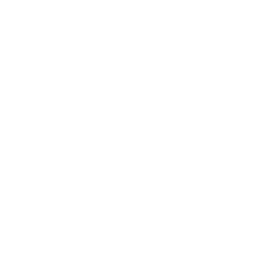
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Split-Plot-ontwerp voor procesoptimalisatie</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Productie / Kwaliteitstechniek &nbsp;|&nbsp; maart 2026</p>
</div>
</div>
</div>

## Samenvatting

Deze notebook analyseert een split-plot-experiment voor een spuitgietproces.
De hoofdplot-factor is **machine** (4 niveaus: MACH_A-MACH_D), die moeilijk
te wijzigen is, en de subplot-factor is **snelheidsinstelling** (5 niveaus:
60, 80, 100, 120, 140 RPM), die eenvoudig te wijzigen is. Bij elke combinatie
van machine x snelheid worden vijf herhaalde metingen genomen, wat 100
defectpercentage-observaties oplevert.

`PROC MIXED` past de structuur van beperkte randomisatie correct toe door
**machine als een willekeurig effect** (de foutstratum van de hoofdplot) en
**snelheid als een vast effect** (de subplot-factor) te behandelen. De
analyse schat de twee variantiecomponenten, toetst het snelheidseffect en
produceert Tukey-gecorrigeerde paarsgewijze vergelijkingen van de
kleinste-kwadratengemiddelden van de snelheid om de bedrijfssnelheid te
identificeren die het defectpercentage minimaliseert.


## Gegevensbronnen

| Bron | Beschrijving | Records |
|--------|-------------|--------|
| WORK.MOLDING_EXPERIMENT | Split-plot experimentele gegevens: 4 machines x 5 snelheden x 5 herhalingen | 100 |


---


In [1]:
/* --------------------------------------------------------
   Genereer synthetische split-plot spuitgietgegevens
   4 machines (hoofdplot) x 5 snelheden (subplot) x 5 herh.
   Extra herhalingen voor elke hoofdplot
   -------------------------------------------------------- */
GEGEVENS work.molding_experiment;
    CALL streaminit(42);
    REEKS machine_names[4] $12 _temporary_ ('MACH_A' 'MACH_B' 'MACH_C' 'MACH_D');
    REEKS speed_settings[5] _temporary_ (60 80 100 120 140);
    /* Werkelijke machine-effecten (willekeurig) */
    REEKS mach_eff[4] _temporary_ (2.1 -1.5 0.8 -1.4);
    /* Werkelijke snelheidseffecten (vast, kwadratisch met optimum ~100) */
    REEKS speed_eff[5] _temporary_ (3.2 1.0 -0.5 0.8 4.5);
    obs_id = 0;
    DOE whole_plot = 1 TOT 5;
        DOE m = 1 TOT 4;
            machine = machine_names[m];
            machine_id = cat('WP_', SCHRIJVEN(whole_plot, z2.), '_', machine);
            /* Hoofdplot-herhalingseffect */
            wp_noise = rand('normal', 0, 1.5);
            DOE s = 1 TOT 5;
                speed = speed_settings[s];
                speed_label = cat(SCHRIJVEN(speed, 3.), 'RPM');
                /* Subplot-herhalingen binnen elke hoofdplot */
                DOE rep = 1 TOT 5;
                    obs_id + 1;
                    /* Defectpercentage: intercept + machine + snelheid + interactie + ruis */
                    defect_rate = round(
                        8.0 + mach_eff[m] + speed_eff[s] +
                        wp_noise +
                        0.3 * (m - 2) * (s - 3) +
                        rand('normal', 0, 1.2),
                    0.01);
                    ALS defect_rate < 0 DAN defect_rate = 0.01;
                    /* Secundaire respons: treksterkte */
                    tensile_strength = round(
                        45 - 0.5 * defect_rate +
                        rand('normal', 0, 2),
                    0.1);
                    UITVOER;
                EINDE;
            EINDE;
        EINDE;
    EINDE;
    VERWIJDEREN m s mach_eff1-mach_eff4 speed_eff1-speed_eff5 wp_noise;
UITVOEREN;



NOTE: DATA work.molding_experiment

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.molding_experiment (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.05 seconds
  cpu   0.05 seconds


---


In [2]:
/* --------------------------------------------------------
   Uitgangswaarde: overzicht van defectpercentage per machine en snelheid
   -------------------------------------------------------- */
PROCEDURE GEMIDDELDEN GEGEVENS=work.molding_experiment n mean std;
    KLASSE machine speed_label;
    VARIABELE defect_rate tensile_strength;
    label machine="Machine" speed_label="Snelheidsinstelling"
          defect_rate="Defectpercentage (%)" tensile_strength="Treksterkte";
    TITEL 'Defectpercentage en treksterkte per machine en snelheid';
UITVOEREN;


                                Defectpercentage en treksterkte per machine en snelheid                                 

                                                  The MEANS Procedure

                                  Analysis Variable : defect_rate Defectpercentage (%)

        Machine   Snelheidsinstelling          N Obs           Mean        Std Dev
        --------------------------------------------------------------------------
        MACH_A     60RPM                           5     12.9460000      1.0100149
        MACH_A     80RPM                           5     10.0160000      0.6740401
        MACH_A    100RPM                           5      7.5980000      0.9787083
        MACH_A    120RPM                           5     10.2660000      0.9490416
        MACH_A    140RPM                           5     13.7120000      0.9359594
        MACH_B     60RPM                           5     11.7420000      0.9476656
        MACH_B     80RPM                           5   


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


                                Defectpercentage en treksterkte per machine en snelheid                                 




NOTE: PROC MEANS
NOTE: Output dataset work.cell_means has 30 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.cell_means

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


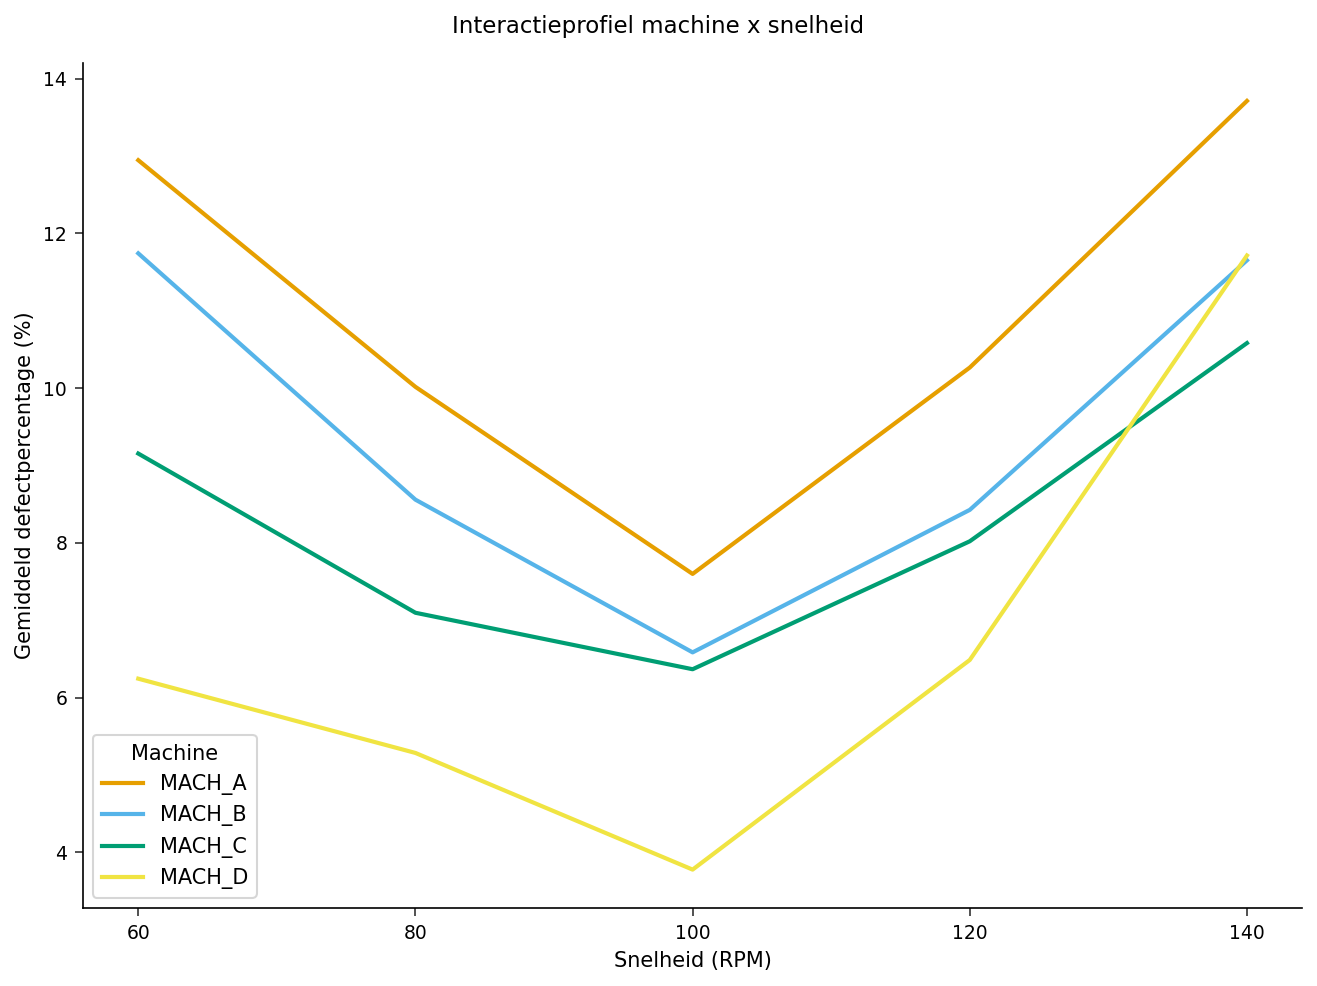

In [3]:
/* --------------------------------------------------------
   Interactieplot: gemiddeld defectpercentage per snelheid en machine
   -------------------------------------------------------- */
PROCEDURE GEMIDDELDEN GEGEVENS=work.molding_experiment NOPRINT;
    KLASSE machine speed;
    VARIABELE defect_rate;
    UITVOER out=work.cell_means mean=mean_defect;
UITVOEREN;

PROCEDURE SGPLOT GEGEVENS=work.cell_means(WAAR=(_type_=3));
    SERIES x=speed y=mean_defect / GROUP=machine
        LINEATTRS=(thickness=2) MARKERS;
    keylegend / TITEL="Machine";
    XAXIS label='Snelheid (RPM)' VALUES=(60 80 100 120 140);
    YAXIS label='Gemiddeld defectpercentage (%)';
    TITEL 'Interactieprofiel machine x snelheid';
UITVOEREN;


---


                                Defectpercentage en treksterkte per machine en snelheid                                 

              The Mixed Procedure              
               Model Information               

Item                                      Value
-------------------------  --------------------
Dependent Variable         Defectpercentage (%)
Estimation Method                          REML
Degrees of Freedom Method         Kenward-Roger
Number of Observations                      100

Covariance Parameter Estimates

Cov Parm   Subject   Estimate
---------  --------  --------
Intercept  machine     3.1033
Residual               1.6566

              Type III Tests of Fixed Effects              

Effect                 Num DF    Den DF   F Value    Pr > F
-------------------  --------  --------  --------  --------
Snelheidsinstelling         4      92.0     60.26    <.0001

         Fit Statistics          

Statistic                   Value
-----------------------  ---


NOTE: PROC MIXED data=work.molding_experiment

NOTE: PROC MIXED: using R wrapper (mixed_renderer.R).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: lmer formula: defect_rate ~ speed_label + (1 | machine)
NOTE: Warning message:
NOTE: In readLines(con = "stdin") : incomplete final line found on 'stdin'
NOTE: ODS plot written: mixed_residuals_vs_predicted.spec.json
NOTE: ODS plot written: mixed_residual_histogram_panel.spec.json
NOTE: ODS plot written: mixed_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: mixed_qq_plot.spec.json
NOTE: ODS plot written: mixed_diagnostics.spec.json
NOTE: PROC MIXED ODS Graphics generated.
NOTE: ODS OUTPUT: SolutionF written to 'split_fixed'.
NOTE: ODS OUTPUT: CovParms written to 'split_covparms'.
NOTE: ODS OUTPUT: LSMeans written to 'speed_lsmeans'.
NOTE: ODS OUTPUT: FitStatistics written to 'split_fit'.
NOTE: ODS OUTPUT: Diffs written to 'speed_diffs'.


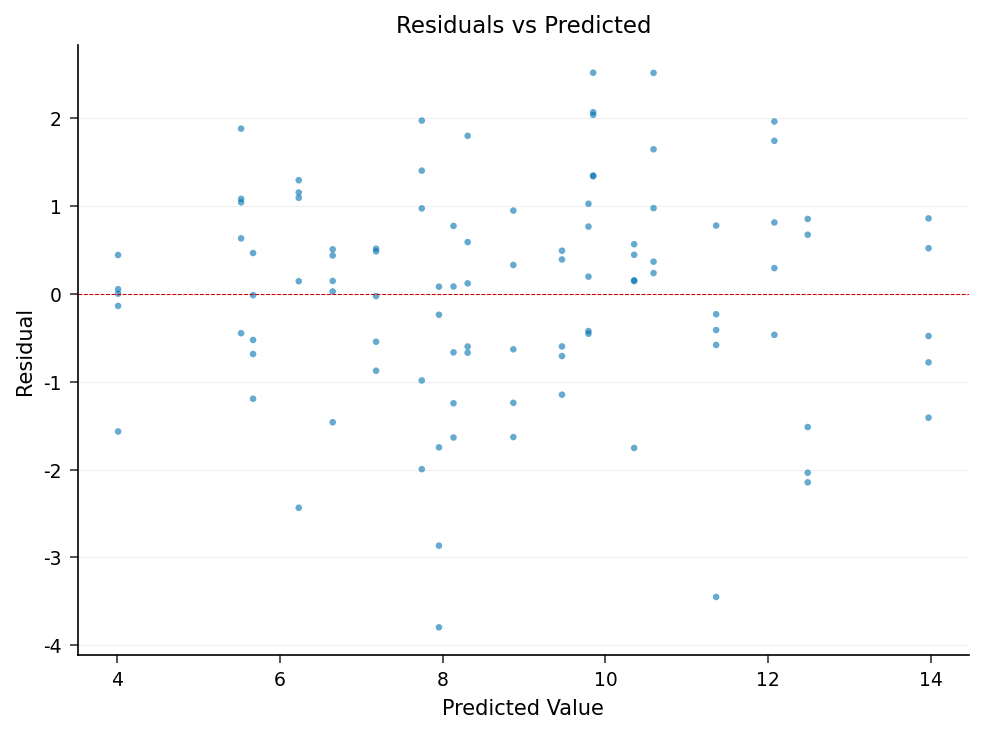

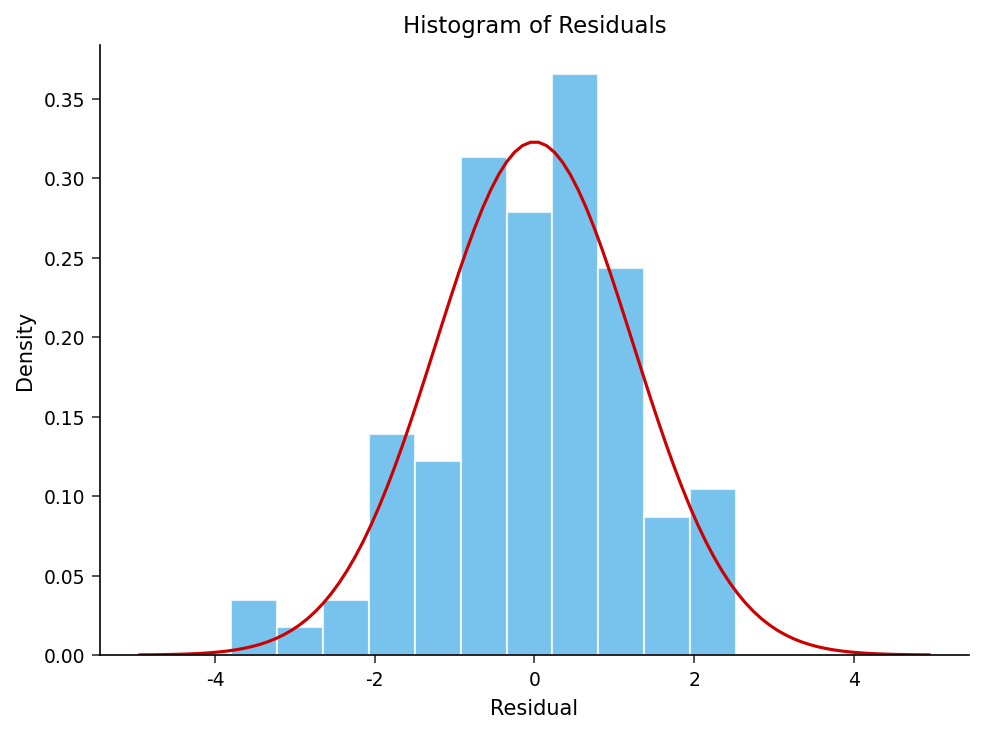

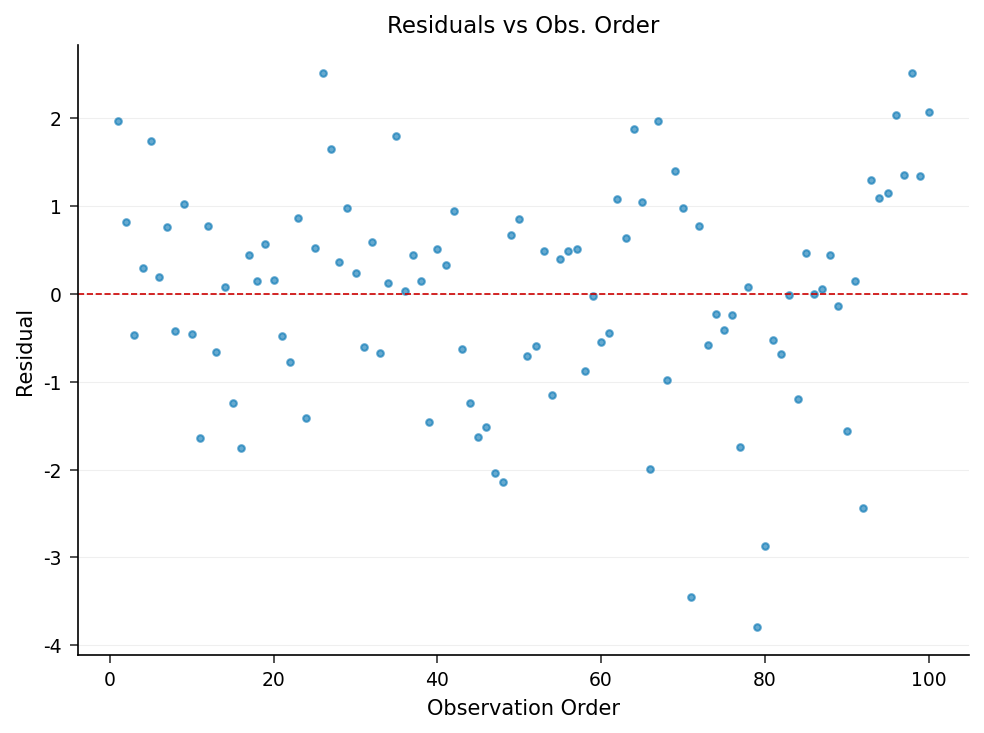

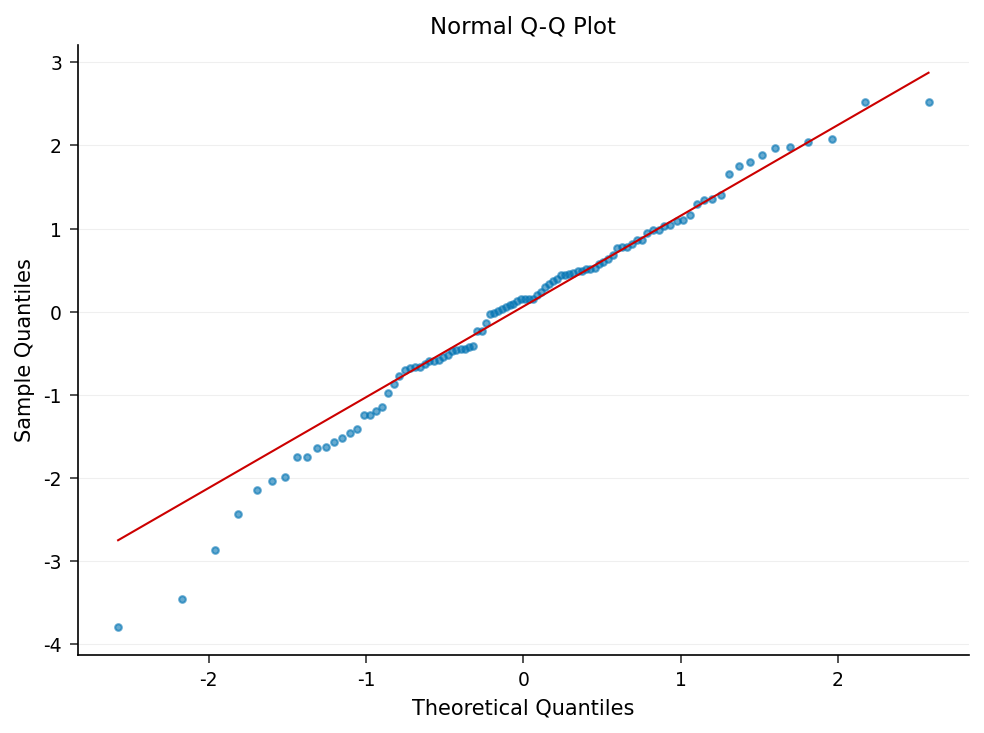

In [4]:
/* --------------------------------------------------------
   Split-plot mixed-model-analyse
   Machine is willekeurig (hoofdplot-fout)
   Snelheid is vast (subplot-factor)
   -------------------------------------------------------- */
PROCEDURE MIXED GEGEVENS=work.molding_experiment METHOD=reml;
    KLASSE machine speed_label;
    MODEL defect_rate = speed_label / SOLUTION ddfm=kr;
    RANDOM machine;
    LSMEANS speed_label / ADJUST=TUKEY DIFF cl;
    label defect_rate="Defectpercentage (%)" speed_label="Snelheidsinstelling"
          machine="Machine";
    ODS output LSMEANS=work.speed_lsmeans
              diffs=work.speed_diffs
              covparms=work.split_covparms
              fitstatistics=work.split_fit
              solutionf=work.split_fixed;
    TITEL 'Split-plot-analyse: effect van snelheid op defectpercentage';
UITVOEREN;


In [5]:
/* --------------------------------------------------------
   Identificeer de optimale snelheidsinstelling
   -------------------------------------------------------- */
PROCEDURE SORTEREN GEGEVENS=work.speed_lsmeans;
    VOLGENS ESTIMATE;
UITVOEREN;

GEGEVENS work.optimal_speed;
    INSTELLEN work.speed_lsmeans(obs=1);
    BEWAREN speed_label ESTIMATE stderr LOWER UPPER;
    label speed_label = 'Optimale snelheid'
          ESTIMATE = 'LS-gemiddeld defectpercentage'
          LOWER = '95%-BI ondergrens'
          UPPER = '95%-BI bovengrens';
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=work.optimal_speed noobs label;
    TITEL 'Aanbevolen bedrijfssnelheid voor minimaal defectpercentage';
UITVOEREN;


                               Aanbevolen bedrijfssnelheid voor minimaal defectpercentage                               

Optimale snelheid  LS-gemiddeld defectpercentage  StdErr  95%-BI ondergrens  95%-BI bovengrens
                .                          6.081  0.9266             3.3645             8.7975




NOTE: PROC SORT data=work.speed_lsmeans

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from work.speed_lsmeans.
NOTE: Wrote work.speed_lsmeans (5 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.optimal_speed


NOTE: Read 1 rows from work.speed_lsmeans.
NOTE: Wrote work.optimal_speed (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.optimal_speed

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


In [6]:
/* --------------------------------------------------------
   Ontleding van de variantiecomponenten
   -------------------------------------------------------- */
PROCEDURE AFDRUKKEN GEGEVENS=work.split_covparms noobs;
    TITEL 'Variantiecomponenten: machine versus residu';
UITVOEREN;


                                      Variantiecomponenten: machine versus residu                                       

  COVPARM  ESTIMATE
Intercept    3.1033
Residual     1.6566




NOTE: PROC PRINT data=work.split_covparms

NOTE: PROC PRINT completed: 2 observations printed, 2 variables


---


### Interpretatie

Het split-plot-model splitst de variabiliteit in defectpercentage op in twee
strata. De **variantiecomponent van machine (hoofdplot) is 3,10** en de
**residuele variantie (subplot) is 1,66**, dus verschillen tussen machines
verklaren ongeveer **65%** van de totale variantie (3,10 / (3,10 + 1,66)).
Dit grote aandeel tussen machines bevestigt dat machine een echte bron van
procesvariatie is en dat het split-plot-ontwerp - in plaats van een volledig
gerandomiseerde analyse - het juiste kader is.

De Type III-toets van het vaste snelheidseffect is sterk significant:
**F(4, 92) = 60,26, p < ,0001**, dus de RPM-instelling heeft een sterke
invloed op het defectpercentage. De kleinste-kwadratengemiddelden tekenen
een duidelijke kwadratische respons met een minimum bij de middelste
snelheid:

| Snelheid | LS-gemiddeld defectpercentage (%) | 95%-BI |
|-------|------------------------|--------|
| **100 RPM** | **6,08** | 3,36 - 8,80 |
| 80 RPM | 7,74 | 5,02 - 10,46 |
| 120 RPM | 8,30 | 5,58 - 11,02 |
| 60 RPM | 10,02 | 7,31 - 12,74 |
| 140 RPM | 11,92 | 9,20 - 14,63 |

Tukey-gecorrigeerde paarsgewijze vergelijkingen tonen dat **100 RPM
significant lager is dan elke andere instelling** (gecorrigeerde p <= 0,0009
tegenover 80, 120, 60 en 140 RPM). De instellingen 80 RPM en 120 RPM zitten
in het midden en verschillen **niet** van elkaar (verschil 0,56, gecorrigeerde
p = 0,6430), terwijl 60 RPM en 140 RPM de hoogste defectpercentages
opleveren.

**Aanbeveling voor engineering:** standaardiseer de productie op **100 RPM**
op alle vier machines, waar het model het laagste defectpercentage schat
(6,08%). Omdat de variantiecomponent van machine (3,10) de dominante bron
van variabiliteit is, moet vervolgwerk zich richten op machinespecifieke
kalibratie - het interactieprofiel laat zien dat MACH_D consistent het
laagst en MACH_A het hoogst presteert - om het verschil tussen machines bij
het gekozen instelpunt van 100 RPM te dichten.


---


In [7]:
/* --------------------------------------------------------
   Exporteer snelheidsoptimalisatie-resultaten voor engineering
   -------------------------------------------------------- */
PROCEDURE EXPORTEREN GEGEVENS=work.speed_lsmeans
    OUTFILE='speed_optimization_lsmeans.csv'
    DBMS=csv REPLACE;
UITVOEREN;

PROCEDURE EXPORTEREN GEGEVENS=work.split_covparms
    OUTFILE='variance_components.csv'
    DBMS=csv REPLACE;
UITVOEREN;



NOTE: PROC EXPORT data=work.speed_lsmeans outfile=speed_optimization_lsmeans.csv

NOTE: Exported 5 rows to speed_optimization_lsmeans.csv.
NOTE: PROC EXPORT data=work.split_covparms outfile=variance_components.csv

NOTE: Exported 2 rows to variance_components.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertrouwelijk
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Mogelijk gemaakt door <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>